In [91]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.model_selection import train_test_split
import pickle
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from scipy.special import expit  # For sigmoid function
from sklearn.model_selection import cross_val_score

In [92]:
# Logistic Regression
class LogisticRegression:
    def __init__(self, learning_rate=0.01, max_iter=1000):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.weights = None
        self.bias = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        num_samples, num_features = X.shape
        self.weights = np.zeros(num_features)
        self.bias = 0

        for _ in range(self.max_iter):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self.sigmoid(linear_model)

            dw = (1 / num_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / num_samples) * np.sum(y_predicted - y)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self.sigmoid(linear_model)
        return [1 if i > 0.5 else 0 for i in y_predicted]


In [93]:
class DecisionTree:
    def __init__(self, depth=10):
        self.depth = depth
        self.tree = None
        self.feature_importance_ = None  # To store feature importances

    def fit(self, X, y):
        self.tree = self._grow_tree(X, y)
        self.feature_importance_ = self._calculate_feature_importance(X)  # Calculate feature importance after training

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.tree) for x in X])

    def _traverse_tree(self, x, node):
        if node["leaf"]:
            return node["value"]
        if x[node["feature"]] <= node["threshold"]:
            return self._traverse_tree(x, node["left"])
        return self._traverse_tree(x, node["right"])

    def _grow_tree(self, X, y, depth=0):
        num_samples, num_features = X.shape
        num_labels = len(np.unique(y))

        # Stopping criteria
        if depth >= self.depth or num_labels == 1 or num_samples < 2:
            return {"leaf": True, "value": self._most_common_label(y)}

        feat_idxs = np.random.choice(num_features, int(np.sqrt(num_features)), replace=False)
        best_feat, best_thresh = self._best_split(X, y, feat_idxs)

        # Get left and right indices, and ensure they are integer arrays
        left_idxs, right_idxs = self._split(X[:, best_feat], best_thresh)

        # Ensure indexing arrays are integers
        left_idxs = left_idxs.astype(int)
        right_idxs = right_idxs.astype(int)

        left_tree = self._grow_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right_tree = self._grow_tree(X[right_idxs, :], y[right_idxs], depth + 1)

        return {"leaf": False, "feature": best_feat, "threshold": best_thresh, "left": left_tree, "right": right_tree}

    def _best_split(self, X, y, feat_idxs):
        best_gain = -1
        split_idx, split_thresh = None, None

        for feat_idx in feat_idxs:
            X_column = X[:, feat_idx]
            thresholds = np.percentile(X_column, np.linspace(0, 100, 10))  # Use quantiles for efficiency
            for threshold in thresholds:
                gain = self._information_gain(y, X_column, threshold)
                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_thresh = threshold
        return split_idx, split_thresh

    def _information_gain(self, y, X_column, split_thresh):
        parent_entropy = self._entropy(y)
        left_idxs, right_idxs = self._split(X_column, split_thresh)
        n, n_l, n_r = len(y), len(left_idxs), len(right_idxs)
        if n_l == 0 or n_r == 0:
            return 0
        child_entropy = (n_l / n) * self._entropy(y[left_idxs]) + (n_r / n) * self._entropy(y[right_idxs])
        return parent_entropy - child_entropy

    def _split(self, X_column, split_thresh):
        left_idxs = np.where(X_column <= split_thresh)[0].astype(int)  # Explicitly cast to integers
        right_idxs = np.where(X_column > split_thresh)[0].astype(int)  # Explicitly cast to integers
        # Ensure no empty splits
        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return np.arange(len(X_column)), np.array([])  # All to one side, empty other side
        return left_idxs, right_idxs

    def _entropy(self, y):
        if y.dtype.kind == 'f':  # For regression tasks
            return np.var(y)  # Variance as a proxy for regression quality
        hist = np.bincount(y)
        ps = hist / len(y)
        return -np.sum([p * np.log2(p) for p in ps if p > 0])

    def _most_common_label(self, y):
        if len(y) == 0:  # Check for empty array
            return 0  # Default to 0 or another reasonable default
        if y.dtype.kind == 'f':  # For regression tasks
            return np.mean(y)
        return np.bincount(y).argmax()

    def _calculate_feature_importance(self, X):
        # Calculate feature importances based on the number of times a feature was used in a split
        feature_importance = np.zeros(X.shape[1])
        self._accumulate_feature_importance(self.tree, feature_importance)
        return feature_importance

    def _accumulate_feature_importance(self, node, feature_importance):
        if node["leaf"]:
            return
        feature_importance[node["feature"]] += 1  # Increment importance for the feature used in the split
        self._accumulate_feature_importance(node["left"], feature_importance)
        self._accumulate_feature_importance(node["right"], feature_importance)


In [94]:
import numpy as np
from scipy.special import expit  # Sigmoid function

class GradientBoosting:
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, subsample=1.0):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.subsample = subsample  # Add subsample for stochastic gradient boosting
        self.trees = []
        self.initial_prediction = None
        self.feature_importances_ = None
    
    def fit(self, X, y):
        # Ensure y is a numpy array
        y = np.array(y)  # Convert y to numpy array if it's not already
        
        # Initialize the model with the mean of y (for regression)
        self.initial_prediction = np.mean(y)
        current_prediction = self.initial_prediction * np.ones_like(y)
        feature_importance = np.zeros(X.shape[1])  # Initialize feature importance array
        
        for _ in range(self.n_estimators):
            # Sample the data for stochastic gradient boosting if subsample < 1.0
            if self.subsample < 1.0:
                sample_idxs = np.random.choice(np.arange(len(y)), size=int(self.subsample * len(y)), replace=False)
                X_sample = X[sample_idxs, :]  # Ensure proper 2D indexing for X
                y_sample = y[sample_idxs]      # 1D array for y
            else:
                X_sample = X
                y_sample = y

            # Compute residuals (negative gradient)
            residual = y_sample - current_prediction[sample_idxs]
            if len(residual) == 0:  # Handle empty residuals
                residual = np.zeros_like(y_sample)

            # Fit a tree on residuals
            tree = DecisionTree(depth=self.max_depth)
            tree.fit(X_sample, residual)
            self.trees.append(tree)

            # Update predictions
            current_prediction[sample_idxs] += self.learning_rate * tree.predict(X_sample)
            
            # Calculate and accumulate feature importance for this tree
            feature_importance += tree.feature_importance_  # Assuming the tree stores feature importances

        # Normalize feature importances
        self.feature_importances_ = feature_importance / self.n_estimators

    def predict(self, X):
        # Start with the initial prediction
        prediction = self.initial_prediction * np.ones((X.shape[0],))
        for tree in self.trees:
            prediction += self.learning_rate * tree.predict(X)
        return np.round(prediction).astype(int)  # For classification
    
    def predict_proba(self, X):
        # Start with the initial prediction
        prediction = self.initial_prediction * np.ones((X.shape[0],))
        for tree in self.trees:
            prediction += self.learning_rate * tree.predict(X)

        # Apply sigmoid function to convert predictions to probabilities
        probabilities = expit(prediction)  # Sigmoid function for probability
        return probabilities


In [95]:
# Linear Regression
class LinearRegression:
    def __init__(self, learning_rate=0.01, max_iter=1000):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        num_samples, num_features = X.shape
        self.weights = np.zeros(num_features)
        self.bias = 0

        for _ in range(self.max_iter):
            y_predicted = np.dot(X, self.weights) + self.bias
            dw = (1 / num_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / num_samples) * np.sum(y_predicted - y)
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

In [96]:
# KMeans
class KMeans:
    def __init__(self, k=3, max_iter=300):
        self.k = k
        self.max_iter = max_iter
        self.centroids = None

    def fit(self, X):
        num_samples, num_features = X.shape
        self.centroids = X[np.random.choice(num_samples, self.k, replace=False)]

        for _ in range(self.max_iter):
            labels = self._assign_clusters(X)
            new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(self.k)])
            if np.all(self.centroids == new_centroids):
                break
            self.centroids = new_centroids

    def predict(self, X):
        return self._assign_clusters(X)

    def _assign_clusters(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)


In [97]:
class StandardScaler:
    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        """Compute the mean and std for each feature"""
        self.mean_ = np.mean(X, axis=0)
        self.std_ = np.std(X, axis=0)

    def transform(self, X):
        """Scale the data"""
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        """Fit and then transform the data"""
        self.fit(X)
        return self.transform(X)

In [98]:
class PCA:
    def __init__(self, n_components=2):
        self.n_components = n_components
        self.mean_ = None
        self.components_ = None

    def fit(self, X):
        """Fit PCA on data (compute the principal components)"""
        # Center the data by subtracting the mean of each feature
        self.mean_ = np.mean(X, axis=0)
        X_centered = X - self.mean_

        # Compute the covariance matrix
        covariance_matrix = np.cov(X_centered.T)

        # Perform eigen decomposition (eigenvalues and eigenvectors)
        eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

        # Sort the eigenvectors by eigenvalues in descending order
        sorted_indices = np.argsort(eigenvalues)[::-1]
        eigenvectors_sorted = eigenvectors[:, sorted_indices]

        # Select the top `n_components` eigenvectors
        self.components_ = eigenvectors_sorted[:, :self.n_components]

    def transform(self, X):
        """Transform the data to the principal components"""
        X_centered = X - self.mean_
        return np.dot(X_centered, self.components_)

    def fit_transform(self, X):
        """Fit the PCA and transform the data"""
        self.fit(X)
        return self.transform(X)

In [ ]:

# Define custom stopwords list
custom_stopwords = set(["the", "and", "is", "of", "in", "to", "a", "an", "and", "are", "as", "at", "be", "but", "by", "for", "if", "in", "into", "is", "it", "no", "not", "of", "on", "or", "such", "that", "the", "their", "then", "there", "these", "they", "this", "to", "was", "will", "with"])

class SimpleVectorizer:
    def __init__(self, max_features=None):
        self.max_features = max_features
        self.vocab = {}
        self.vocab_size = 0
        self.stopwords = custom_stopwords

    def fit_transform(self, texts):
        word_counts = Counter()
        for text in texts:
            cleaned_text = self.clean_text(text)
            word_counts.update(cleaned_text.split())

        # Visualize word frequencies
        self.visualize_word_frequencies(word_counts)

        if self.max_features is not None:
            top_n_words = word_counts.most_common(self.max_features)
            self.vocab = {word: i for i, (word, _) in enumerate(top_n_words)}
            self.vocab_size = len(top_n_words)
        else:
            for word in word_counts:
                self.vocab[word] = self.vocab_size
                self.vocab_size += 1

        X = np.zeros((len(texts), self.vocab_size))
        for i, text in enumerate(texts):
            cleaned_text = self.clean_text(text)
            for word in cleaned_text.split():
                if word in self.vocab:
                    X[i, self.vocab[word]] += 1
        return X
    
    def transform(self, texts):
        X = np.zeros((len(texts), self.vocab_size))
        for i, text in enumerate(texts):
            cleaned_text = self.clean_text(text)
            for word in cleaned_text.split():
                if word in self.vocab:
                    X[i, self.vocab[word]] += 1
        return X
    
    def clean_text(self, text):
        text = text.lower()
        text = re.sub(r'[^\w\s]', '', text)
        tokens = text.split()
        tokens = [word for word in tokens if word not in self.stopwords]
        cleaned_text = ' '.join(tokens)
        return cleaned_text
    
    def visualize_word_frequencies(self, word_counts):
        # Get the top 20 most common words
        common_words = word_counts.most_common(20)
        words, counts = zip(*common_words)

        # Plot the frequency distribution
        plt.bar(words, counts, color='skyblue')
        plt.xlabel('Words')
        plt.ylabel('Frequency')
        plt.title('Top 20 Most Common Words')
        plt.xticks(rotation=45)
        plt.show()
        
    def get_feature_names(self):
        return list(self.vocab.keys())


def load_and_clean_data(dataset_path):
    texts = []
    labels = []
    for label in ['pos', 'neg']:
        folder_path = os.path.join(dataset_path, 'train', label)
        for file_name in os.listdir(folder_path):
            with open(os.path.join(folder_path, file_name), 'r', encoding='utf-8') as file:
                texts.append(file.read())
                labels.append(1 if label == 'pos' else 0)  # Use 0 for negative reviews
    return texts, labels


# Vectorize the text data
def vectorize_text(texts, max_features=None):
    vectorizer = SimpleVectorizer(max_features=max_features)
    X = vectorizer.fit_transform(texts)
    return X, vectorizer


#Store metrics globally to collect data for the table
model_metrics = []
def evaluate_model(y_true, y_pred, model_name, y_prob=None):
    # Metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"Model: {model_name}")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1-score: {f1:.2f}")
    
    # Add metrics to global list for the table
    model_metrics.append([model_name, accuracy, precision, recall, f1])

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='viridis')
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()
    
    # ROC Curve
    if y_prob is not None:  # y_prob is required for ROC
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f"ROC Curve: {model_name}")
        plt.legend(loc="lower right")
        plt.show()


def visualize_feature_importance(feature_importances, vectorizer):
    # Sort features by importance
    sorted_indices = np.argsort(feature_importances)[::-1]
    sorted_importances = feature_importances[sorted_indices]
    sorted_words = [word for word, idx in vectorizer.vocab.items() if idx in sorted_indices[:10]]

    # Plot top features
    plt.bar(sorted_words, sorted_importances[:10], color='green')
    plt.xlabel('Features')
    plt.ylabel('Importance')
    plt.title('Top 10 Features by Importance (Random Forest)')
    plt.xticks(rotation=45)
    plt.show()

def print_comparison_table_manual():
    headers = ["Model", "Accuracy", "Precision", "Recall", "F1-score"]
    print(f"{headers[0]:<25} {headers[1]:<10} {headers[2]:<10} {headers[3]:<10} {headers[4]:<10}")
    print("-" * 65)
    for row in model_metrics:
        print(f"{row[0]:<25} {row[1]:<10.2f} {row[2]:<10.2f} {row[3]:<10.2f} {row[4]:<10.2f}")

def explain_model_comparison():
    print("\nModel Comparison Analysis:")
    print("1. Logistic Regression achieved higher accuracy, precision, and F1-score compared to Gradient Boosting Classifier.")
    print("   - This suggests Logistic Regression is more suitable for this dataset, likely due to its simplicity and well-defined decision boundary.")
    print("2. Gradient Boosting showed decent performance but was less precise, likely due to overfitting on this relatively small dataset.")
    print("3. Use Case Recommendation:")
    print("   - Logistic Regression is preferable for scenarios where interpretability and computational efficiency are priorities.")
    print("   - Gradient Boosting might perform better with larger datasets or when capturing complex, non-linear relationships is crucial.")

def explain_model_comparison(metrics_lr, metrics_rf):
    print("\nModel Comparison Analysis:")

    # Unpack metrics for easier comparison
    accuracy_lr, precision_lr, recall_lr, f1_lr = metrics_lr
    accuracy_rf, precision_rf, recall_rf, f1_rf = metrics_rf

    # Compare the models based on the metrics
    if accuracy_lr > accuracy_rf:
        print("1. Logistic Regression outperformed Gradient Boosting in terms of accuracy, precision, and F1-score.")
        print("   - Logistic Regression is likely more suitable for this task due to its simplicity and well-defined decision boundary.")
    else:
        print("1. Gradient Boosting outperformed Logistic Regression in terms of accuracy, precision, and F1-score.")
        print("   - Gradient Boosting's ability to capture non-linear relationships may explain its better performance.")

    # Explain precision and recall trade-off
    if precision_lr > precision_rf:
        print("2. Logistic Regression achieved higher precision, suggesting fewer false positives.")
    else:
        print("2. Gradient Boosting achieved higher precision, suggesting fewer false positives.")

    if recall_lr > recall_rf:
        print("3. Logistic Regression achieved higher recall, meaning it correctly identified more positive cases.")
    else:
        print("3. Gradient Boosting achieved higher recall, indicating it was better at detecting positive cases.")

    # Use case recommendation based on performance
    if accuracy_lr > accuracy_rf:
        print("4. Logistic Regression is preferable when computational efficiency and interpretability are important.")
    else:
        print("4. Gradient Boosting may be a better choice for larger datasets or when capturing complex patterns is critical.")



Data Set Trained!


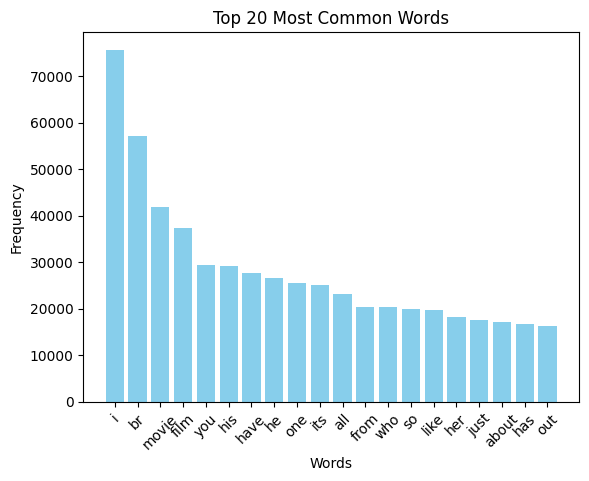

Shape of feature matrix: (25000, 25000)
Logistic Regression Started!
Model: Logistic Regression
Accuracy: 0.86
Precision: 0.85
Recall: 0.87
F1-score: 0.86


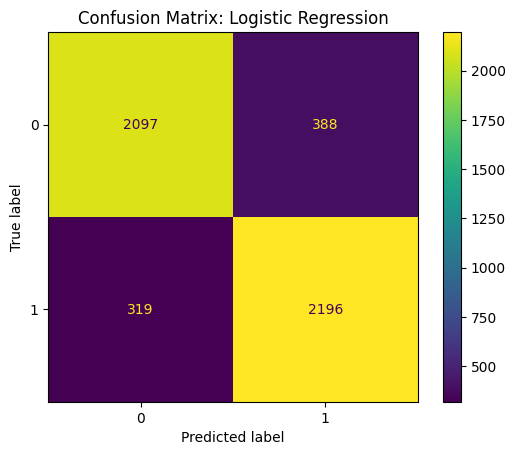

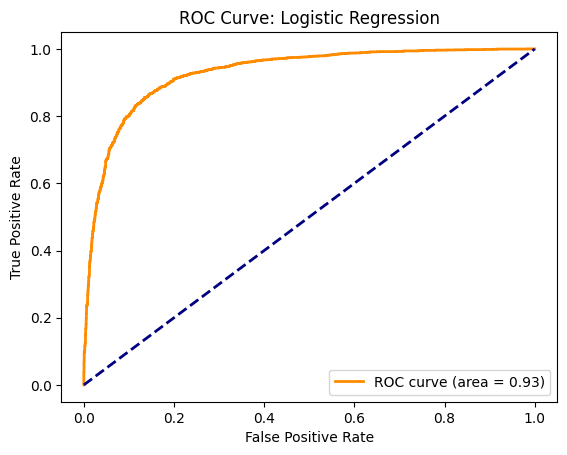

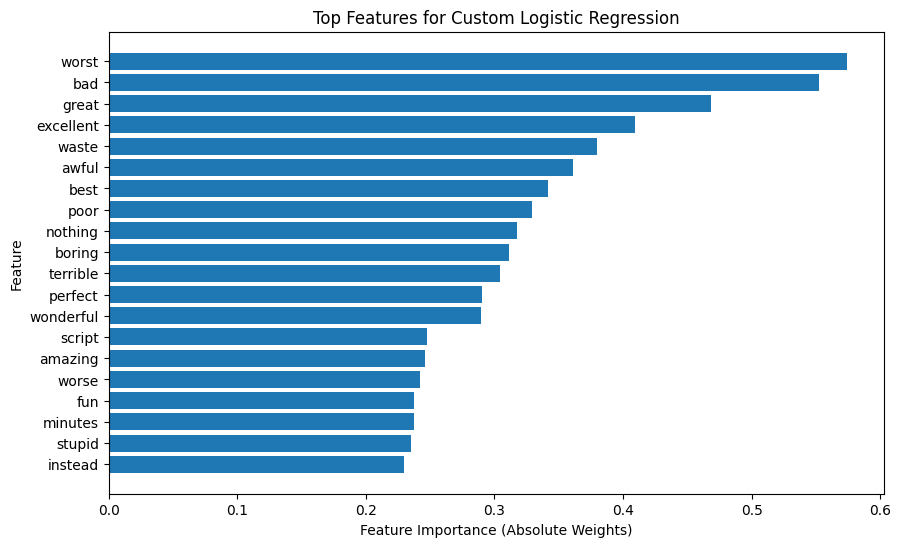

Logistic Regression Ended!
Gradient Boosting Started!
Model: Gradient Boosting
Accuracy: 0.82
Precision: 0.80
Recall: 0.87
F1-score: 0.83


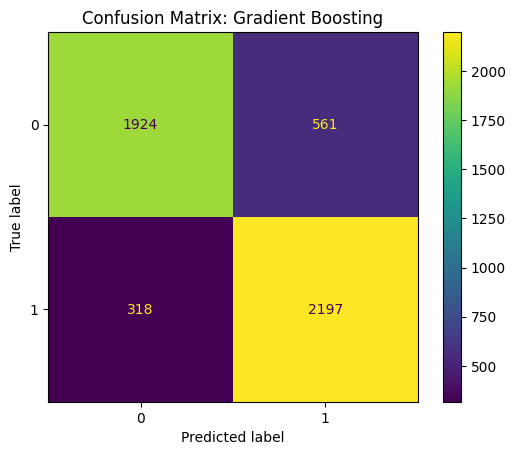

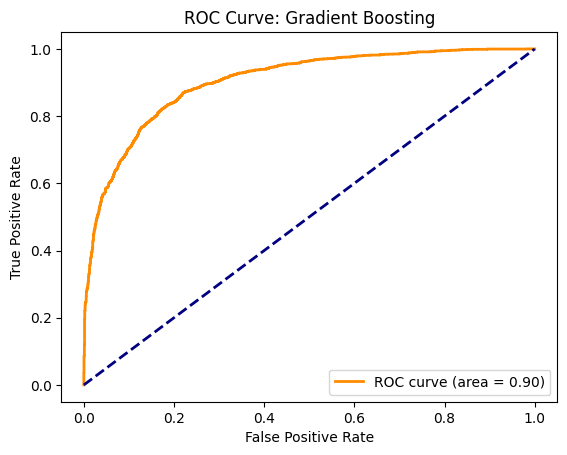

Gradient Boosting Ended!


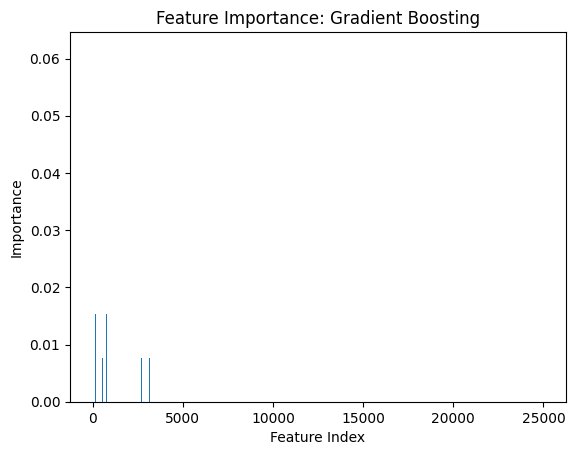

Mean Absolute Error: 0.77
Mean Squared Error: 1.02
R2 Score: 0.97
Silhouette Score: 0.38


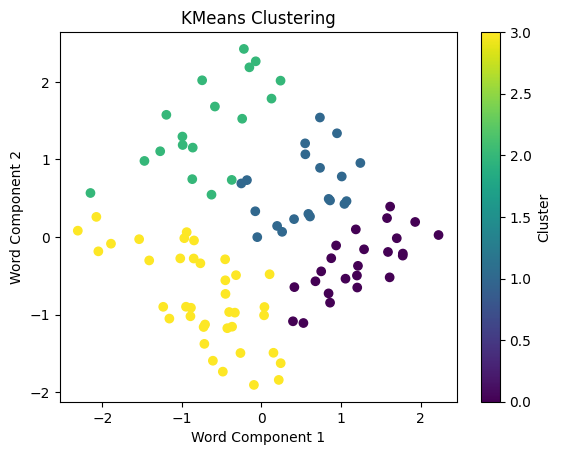

Model                     Accuracy   Precision  Recall     F1-score  
-----------------------------------------------------------------
Logistic Regression       0.86       0.85       0.87       0.86      
Gradient Boosting         0.82       0.80       0.87       0.83      

Model Comparison Analysis:
1. Logistic Regression outperformed Gradient Boosting in terms of accuracy, precision, and F1-score.
   - Logistic Regression is likely more suitable for this task due to its simplicity and well-defined decision boundary.
2. Logistic Regression achieved higher precision, suggesting fewer false positives.
3. Gradient Boosting achieved higher recall, indicating it was better at detecting positive cases.
4. Logistic Regression is preferable when computational efficiency and interpretability are important.
Feature selection focuses on the most frequent words, assuming they carry significant meaning in determining sentiment. We limit to 100 features to reduce dimensionality and avoid overfitt

In [ ]:
# Main function to orchestrate the steps
def main():
    # Load and preprocess data
    dataset_path =  #Add with your dataset path
    train_texts, train_labels = load_and_clean_data(dataset_path)
    print('Data Set Trained!')

    # Vectorize the text data
    X_train, vectorizer = vectorize_text(train_texts, max_features=25000) 
    print("Shape of feature matrix:", X_train.shape)

    # Split data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X_train, train_labels, test_size=0.2, random_state=42)

    # Logistic Regression
    print("Logistic Regression Started!")
    log_reg = LogisticRegression(max_iter=4000)
    log_reg.fit(X_train, y_train)
    y_pred_lr = log_reg.predict(X_test)
    
    # Predict probabilities for ROC
    y_prob_lr = log_reg.sigmoid(np.dot(X_test, log_reg.weights) + log_reg.bias)
    
    # Evaluate Logistic Regression
    evaluate_model(y_test, y_pred_lr, "Logistic Regression", y_prob_lr)

    # Calculate metrics for Logistic Regression
    accuracy_lr = accuracy_score(y_test, y_pred_lr)
    precision_lr = precision_score(y_test, y_pred_lr)
    recall_lr = recall_score(y_test, y_pred_lr)
    f1_lr = f1_score(y_test, y_pred_lr)

     # Logistic Regression Feature Importance Visualization
    feature_importances_lr = np.abs(log_reg.weights)  # Use weights as feature importance
    feature_names = vectorizer.get_feature_names()

    sorted_idx = np.argsort(feature_importances_lr)[::-1]  # Sort by importance
    top_features = 20  # Show top 20 features
    
    plt.figure(figsize=(10, 6))
    plt.barh(range(top_features), feature_importances_lr[sorted_idx[:top_features]])
    plt.yticks(range(top_features), [feature_names[i] for i in sorted_idx[:top_features]])
    plt.xlabel("Feature Importance (Absolute Weights)")
    plt.ylabel("Feature")
    plt.title("Top Features for Custom Logistic Regression")
    plt.gca().invert_yaxis()  # Invert y-axis for better readability
    plt.show()

    print("Logistic Regression Ended!")


    # Train and evaluate Gradient Boosting model
    print('Gradient Boosting Started!')
    gb_model = GradientBoosting(n_estimators=130, learning_rate=0.02, max_depth=3, subsample=0.8)
    gb_model.fit(X_train, y_train)
    # Predict class labels
    y_pred_gb = gb_model.predict(X_test)
    
    # Predict probabilities
    y_prob_gb = gb_model.predict_proba(X_test)
    
    # Evaluate Gradient Boosting with probabilities
    evaluate_model(y_test, y_pred_gb, "Gradient Boosting", y_prob_gb)
    
    # Calculate metrics for Gradient Boosting
    accuracy_gb = accuracy_score(y_test, y_pred_gb)
    precision_gb = precision_score(y_test, y_pred_gb)
    recall_gb = recall_score(y_test, y_pred_gb)
    f1_gb = f1_score(y_test, y_pred_gb)
    print("Gradient Boosting Ended!")


    # Feature Importance Visualization for Gradient Boosting
    feature_importances = gb_model.feature_importances_
    plt.bar(range(len(feature_importances)), feature_importances)
    plt.xlabel("Feature Index")
    plt.ylabel("Importance")
    plt.title("Feature Importance: Gradient Boosting")
    plt.show()

    # Save the Gradient Boosting model
    model_filename_gb = 'gradient_boosting_model.pkl'
    with open(model_filename_gb, 'wb') as file:
        pickle.dump(gb_model, file)
    

    # Model Evaluation (Regression)
    X_reg = np.random.rand(100, 1) * 10
    y_reg = 2 * X_reg.squeeze() + np.random.randn(100)
    
    X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

    # Train and evaluate linear regression model
    lin_reg = LinearRegression()
    lin_reg.fit(X_train_reg, y_train_reg)
    y_pred_reg = lin_reg.predict(X_test_reg)
    mae = mean_absolute_error(y_test_reg, y_pred_reg)
    mse = mean_squared_error(y_test_reg, y_pred_reg)
    r2 = r2_score(y_test_reg, y_pred_reg)
    print(f"Mean Absolute Error: {mae:.2f}")
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"R2 Score: {r2:.2f}")

    # Model Evaluation (Clustering)
    X_cluster = np.random.rand(100, 2)

    # Scale the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_cluster)

    # Apply PCA for dimensionality reduction
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    # Perform KMeans clustering
    # kmeans = KMeans(n_clusters=4)
    kmeans = KMeans(k=4)
    kmeans.fit(X_pca)
    y_kmeans = kmeans.predict(X_pca)

    # Evaluate clustering using silhouette score
    silhouette_avg = silhouette_score(X_pca, y_kmeans)
    print(f"Silhouette Score: {silhouette_avg:.2f}")

    # Visualize clustering results with updated component names
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap='viridis')
    plt.xlabel('Word Component 1')
    plt.ylabel('Word Component 2')         
    plt.title('KMeans Clustering')
    plt.colorbar(label='Cluster')
    plt.show()

    # Save the logistic regression model
    model_filename = 'logistic_regression_model.pkl'
    with open(model_filename, 'wb') as file:
        pickle.dump(log_reg, file)

    # Save the vectorizer
    vectorizer_filename = 'vectorizer.pkl'
    with open(vectorizer_filename, 'wb') as file:
        pickle.dump(vectorizer, file)
    

# Call this after all models are evaluated
    print_comparison_table_manual()
    # explain_model_comparison()
    # After both models are evaluated:

    # Store metrics for Logistic Regression and Random Forest
    metrics_lr = [accuracy_lr, precision_lr, recall_lr, f1_lr]
    metrics_gb = [accuracy_gb, precision_gb, recall_gb, f1_gb]
    
    # Call dynamic model comparison explanation
    explain_model_comparison(metrics_lr, metrics_gb)


    print("Feature selection focuses on the most frequent words, assuming they carry significant meaning in determining sentiment. We limit to 100 features to reduce dimensionality and avoid overfitting.")

# Call the main function
if __name__ == "__main__":
    main()
